In [21]:
# % pip install medmnist
# to download the dataset for the medmnist package

In [1]:
import torch 
import numpy as np
import matplotlib.pyplot as plt
import torch 
import torch.nn as nn 
import torchvision.models as models
from medmnist.dataset import PathMNIST
from medmnist import INFO
from torch.utils.data import DataLoader

from torchvision import transforms

/opt/anaconda3/envs/dl/lib/python3.11/site-packages/torchvision/io/image.py:14: UserWarning: Failed to load image Python extension: 'dlopen(/opt/anaconda3/envs/dl/lib/python3.11/site-packages/torchvision/image.so, 0x0006): Library not loaded: @rpath/libjpeg.9.dylib
  Referenced from: <EB3FF92A-5EB1-3EE8-AF8B-5923C1265422> /opt/anaconda3/envs/dl/lib/python3.11/site-packages/torchvision/image.so
  Reason: tried: '/opt/anaconda3/envs/dl/lib/python3.11/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/opt/anaconda3/envs/dl/lib/python3.11/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/opt/anaconda3/envs/dl/lib/python3.11/lib-dynload/../../libjpeg.9.dylib' (no such file), '/opt/anaconda3/envs/dl/bin/../lib/libjpeg.9.dylib' (no such file)'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before

In [2]:
raw_transform = transforms.Compose([
    # transforms.Resize((224,224)),
    transforms.ToTensor(),
])

train_dataset = PathMNIST(split='train', transform=raw_transform, download=True)
val_dataset = PathMNIST(split='val', transform=raw_transform, download=True)
test_dataset = PathMNIST(split='test', transform=raw_transform, download=True)

data_flag = 'pathmnist'
info = INFO[data_flag]

label_map = info['label']

Using downloaded and verified file: /Users/zhangzimo/.medmnist/pathmnist.npz
Using downloaded and verified file: /Users/zhangzimo/.medmnist/pathmnist.npz
Using downloaded and verified file: /Users/zhangzimo/.medmnist/pathmnist.npz


### EDA

In [3]:
print("Dataset name:", data_flag)
print("Task:", info['task'])
print("Number of channels:", info['n_channels'])
print("Number of classes:", len(info['label']))
print("Labels:", info['label'])

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

Dataset name: pathmnist
Task: multi-class
Number of channels: 3
Number of classes: 9
Labels: {'0': 'adipose', '1': 'background', '2': 'debris', '3': 'lymphocytes', '4': 'mucus', '5': 'smooth muscle', '6': 'normal colon mucosa', '7': 'cancer-associated stroma', '8': 'colorectal adenocarcinoma epithelium'}
Train size: 89996
Validation size: 10004
Test size: 7180


In [4]:
img, label = train_dataset[0]

print("Image shape:", img.shape)   # [C, H, W]
print("Label:", label)
print("Image min:", img.min().item())
print("Image max:", img.max().item())

Image shape: torch.Size([3, 28, 28])
Label: [0]
Image min: 0.6431372761726379
Image max: 0.8941176533699036


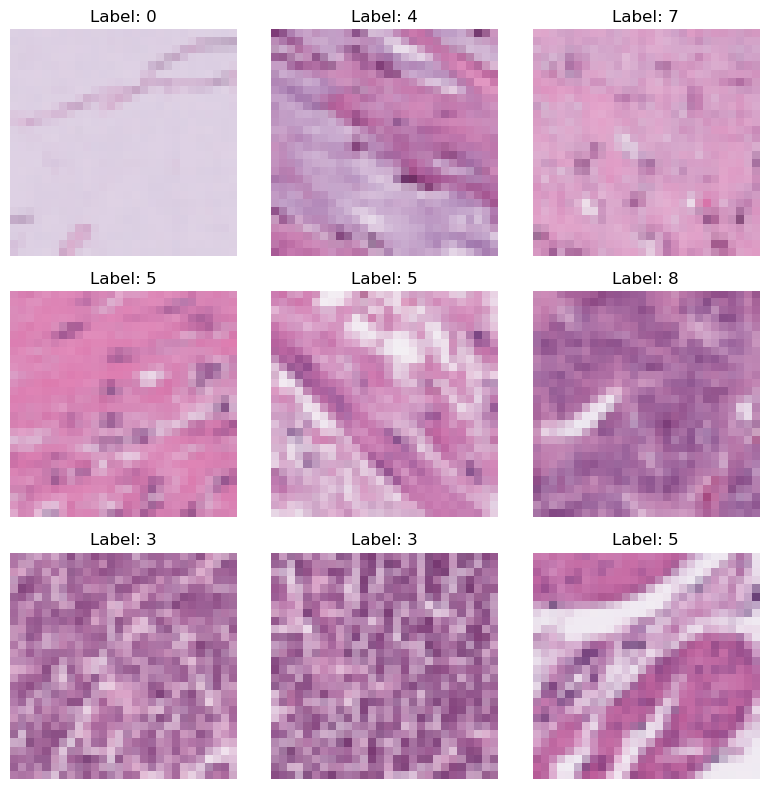

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(8, 8))

for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    
    # PathMNIST usually has 3 channels, so transpose to HWC
    img_np = img.permute(1, 2, 0).numpy()
    
    ax.imshow(img_np)
    ax.set_title(f"Label: {label.item()}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### Preprocessing

In [6]:
# # Normalized the pixel range from 0~1 to -1~1
sd_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.5,0.5,0.5),
        std=(0.5,0.5,0.5)
    )
])

# In order to match the normalization with the perTrained Model, we need to transform the dataset with the same image normalization
pretrainVGG_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    ) # The normalization for the ImageNet
])



train_dataset = PathMNIST(split='train', transform=pretrainVGG_transform, download=True)
val_dataset = PathMNIST(split='val', transform=pretrainVGG_transform, download=True)
test_dataset = PathMNIST(split='test', transform=pretrainVGG_transform, download=True)
train_dataloader = DataLoader(train_dataset, batch_size=128, shuffle=True) 
val_dataloader = DataLoader(val_dataset, batch_size = 128, shuffle=True)

Using downloaded and verified file: /Users/zhangzimo/.medmnist/pathmnist.npz
Using downloaded and verified file: /Users/zhangzimo/.medmnist/pathmnist.npz
Using downloaded and verified file: /Users/zhangzimo/.medmnist/pathmnist.npz


# Architecture Building 

In [7]:
class pretrainVGG16(nn.Module):
    def __init__(self, num_classes=9):
        # Override 
        super(pretrainVGG16, self).__init__()
        
        # Load the pretrained VGG16
        self.vgg16 = models.vgg16(pretrained=True)

        # Freeze the layers of VGG16
        for para in self.vgg16.parameters():
            para.requires_grad = False

        # Replace the last fully connected layer with a new one
        # Make it fits the number of PM classes 
        in_features = self.vgg16.classifier[6].in_features
        self.vgg16.classifier[6] = nn.Linear(
            in_features=in_features,
            out_features=num_classes
        ) 

    def forward(self, x):
        output = self.vgg16(x)
        return output


In [8]:
# model Check
model = pretrainVGG16()
x, y = train_dataset[0]
x = x.unsqueeze(0)
out = model(x)
print(out)

/opt/anaconda3/envs/dl/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/envs/dl/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


tensor([[-0.5412,  0.8669, -0.1506,  0.1203, -0.2219,  0.3889,  0.2903, -0.5162,
          0.8058]], grad_fn=<AddmmBackward0>)


In [9]:
class VGG16(nn.Module):
    def __init__(self, num_classes=9):
        # Override 
        super(VGG16, self).__init__()

        # VGG16 convolution blocks
        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 4
            # nn.Conv2d(256, 512, kernel_size=3, padding=1),
            # nn.ReLU(inplace=True),
            # nn.Conv2d(512, 512, kernel_size=3, padding=1),
            # nn.ReLU(inplace=True),
            # nn.Conv2d(512, 512, kernel_size=3, padding=1),
            # nn.ReLU(inplace=True),
            # nn.MaxPool2d(2, 2),

            # Block 5
            # nn.Conv2d(512, 512, kernel_size=3, padding=1),
            # nn.ReLU(inplace=True),
            # nn.Conv2d(512, 512, kernel_size=3, padding=1),
            # nn.ReLU(inplace=True),
            # nn.Conv2d(512, 512, kernel_size=3, padding=1),
            # nn.ReLU(inplace=True),
            # nn.MaxPool2d(2, 2),
        )

        # classifier
        self.classifier = nn.Sequential(
            nn.Linear(256*28*28, 4096),
            nn.ReLU(True),
            nn.Dropout(),

            nn.Linear(4096, 4096),
            nn.ReLU(True),
            nn.Dropout(),

            nn.Linear(4096, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, start_dim=1)
        output = self.classifier(x)
        return output



In [10]:
# model Check
model = VGG16()
out = model(x)
print(out)

tensor([[-0.0004,  0.0062, -0.0090, -0.0016, -0.0047, -0.0078, -0.0086, -0.0056,
         -0.0153]], grad_fn=<AddmmBackward0>)


In [11]:
class ResNet18(nn.Module):
    def __init__(self, num_classes=9):
        super(ResNet18, self).__init__()

        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # Residual layers 
        self.layer1 = self._make_layer(64,  64,  num_blocks=2, stride=1) 
        self.layer2 = self._make_layer(64,  128, num_blocks=2, stride=2) 
        self.layer3 = self._make_layer(128, 256, num_blocks=2, stride=2)  
        self.layer4 = self._make_layer(256, 512, num_blocks=2, stride=2) 

        # Classifier head (MLP) 
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, in_channels, out_channels, num_blocks, stride):
        layers = [BasicBlock(in_channels, out_channels, stride)]
        for _ in range(1, num_blocks):
            layers.append(BasicBlock(out_channels, out_channels, stride=1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)


class BasicBlock(nn.Module):

    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels,
                                kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.relu  = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(out_channels, out_channels,
                                kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return self.relu(out)

In [10]:
model = ResNet18()
out = model(x)
print(out)

tensor([[ 0.2924, -0.1375, -0.0986,  0.1098,  0.4435,  0.3247, -1.0241,  0.2042,
          0.4702]], grad_fn=<AddmmBackward0>)


In [12]:
class pretrainResNet18(nn.Module):
    def __init__(self, num_classes=9):
        super().__init__()

        self.resnet18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

        for param in self.resnet18.parameters():
            param.requires_grad = False

        self.resnet18.fc = nn.Linear(self.resnet18.fc.in_features, num_classes)

    def forward(self, x):
        return self.resnet18(x)

In [13]:
model = pretrainResNet18()
out = model(x)
print(out)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/zhangzimo/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 51.6MB/s]


tensor([[-1.2326, -0.1108, -0.8525, -0.2797, -0.0236,  0.5458, -0.2937,  0.9317,
          0.1036]], grad_fn=<AddmmBackward0>)


# Training and Hyper-parameter tuning 

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from dataclasses import dataclass, field
from torchvision import transforms
from typing import List, Type
import time
import os

@dataclass
class TrainConfig: 
    ### Training process configs
    epochs: int = 10
    lr: float = 1e-4
    optimizer_cls: Type[torch.optim.Optimizer] = torch.optim.Adam
    device: str = 'cuda' if torch.cuda.is_available() else 'cpu'

    ## Validation configs
    use_validation: bool = True
    early_stopping_patience: int = 3
    early_stopping_metric: str = "accuracy" # Cant use Loss

    ### Data transformer
    transform = None

    ### Checkpoint configs
    save_checkpoints: bool = False 
    checkpoints_dir: dir = "checkpoints"
    save_frequency: int = 2
    save_best_only: bool = True


@dataclass
class TrainHistoryRecords: 
    epochs: List[float] = field(default_factory=list)
    train_losses: List[float] = field(default_factory=list)
    train_accuracies: List[float] = field(default_factory=list)
    valid_losses: List[float] = field(default_factory=list)
    valid_accuracies: List[float] = field(default_factory=list)

def evaluate(model, loader, loss_fn, device):

    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device).float()
            labels = labels.to(device).squeeze().long()

            outputs = model(images)

            loss = loss_fn(outputs, labels)

            total_loss += loss.item() * images.size(0)

            preds = outputs.argmax(1)

            correct += (preds == labels).sum().item()

            total += images.size(0)
    
    output_avg_loss = total_loss/total
    output_accuracy = correct/total 

    return output_avg_loss, output_accuracy

def train(
    model: nn.Module,
    config: TrainConfig,
    # train_loader: DataLoader,
    # valid_loader: DataLoader | None = None
    train_dataset,
    valid_dataset
    ):
    
    # Pre-set config session 
    device = torch.device(config.device)
    model = model.to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = config.optimizer_cls(model.parameters(),
                                     lr=config.lr)
    history = TrainHistoryRecords()
    best_metric = None
    early_stop_idx = 0

    print("+"*41)
    print(f"Training starts on: {device}")
    print("+"*41)
    

    for epoch in range(1, config.epochs + 1):
        model.train()
 
        total_loss = 0.0
        correct = 0
        total = 0
        batch_idx = 0
        start = time.time()

        for images, labels in train_loader:
            images = images.to(device).float()
            labels = labels.to(device).squeeze().long()
 
            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()
 
            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            batch_correct = (preds == labels).sum().item()
            correct += batch_correct
            total += images.size(0)
            # if batch_idx % 50 == 0:
            #     print(f"Batch {batch_idx} ||  Current Batah Loss: {loss.item():<.4} || Current Batah Accuracy: {batch_correct/images.size(0):<.4} || Current Total AvgLoss: {total_loss/total:<.4} || Accuracy: {correct/total:<.4}, ")
            batch_idx += 1
 
        avg_loss = total_loss / total
        accuracy = correct / total
        elpased = time.time() - start
 
        history.epochs.append(epoch)
        history.train_losses.append(avg_loss)
        history.train_accuracies.append(accuracy)
 
        print(f"Epoch: {epoch:<8} || Train Average Loss: {avg_loss:<12.4f} || Train Accuracy: {accuracy:<12.4f} || Train Time Spent: {elpased:<.4}")
        
        if config.use_validation and valid_loader is not None:

            val_loss, val_acc = evaluate(
                model,
                valid_loader,
                loss_fn,
                device
            )

            history.valid_losses.append(val_loss)
            history.valid_accuracies.append(val_acc)

            print(
                f"Validation Average Loss: {val_loss:.4f} || Validation Accuracy: {val_acc:.4f}"
            )

            metric = val_acc if config.early_stopping_metric == "accuracy" else -val_loss

            ### EarlyStop Logics
            if best_metric is None or metric > best_metric:

                best_metric = metric
                early_stop_idx = 0

            else:

                early_stop_idx += 1


        if config.save_checkpoints:
            os.makedirs(config.checkpoints_dir,
                        exist_ok=True)
            
            is_best = accuracy >= max(history.accuracies)
            save_this_epoch = (
                config.save_frequency is not None 
                and
                epoch % config.save_frequency == 0
            )

            if is_best or save_this_epoch:
                checkpoint = {
                    "epoch": epoch,
                    "model_state": model.state_dict(),
                    "optimizer_state": optimizer.state_dict(),
                    "config": config,
                    "history": history
                }

                if is_best and config.save_best_only:
                    ckpt_path = os.path.join(config.checkpoints_dir, "best.pt")
                    torch.save(checkpoint, ckpt_path)
                    print(f"Best checkpoint saved (accuracy={accuracy:.4f}), saveing path is: {ckpt_path}")

                if save_this_epoch:
                    ckpt_path = os.path.join(config.checkpoints_dir, f"epoch_{epoch:03d}.pt")
                    torch.save(checkpoint, ckpt_path)
                    print(f"Epoch checkpoint saved, saveing path is: {ckpt_path}")

            if early_stop_idx >= config.early_stopping_patience:
                print("\nEarly stopping triggered")
                break

        
        
    print("="*41)
    print("Training Completed!")
    return history

In [ ]:
model = pretrainVGG16()
config = TrainConfig(
    epochs=10,
    lr=1e-3,
    optimizer_cls=torch.optim.Adam,
    device="cuda",
    save_checkpoints=True,
    checkpoints_dir="VGG_pretrain",
    save_best_only=True
)
history = train(model = model,
                train_loader = train_dataloader,
                config = config)

In [28]:
model = ResNet18()
config = TrainConfig(
    epochs=10,
    lr=1e-3,
    optimizer_cls=torch.optim.Adam,
    device="cuda",
    save_checkpoints=False,
    checkpoints_dir="ResNet18",
    save_best_only=True,
    early_stopping_metric="accuracy"
)
history = train(model = model,
                train_loader = train_dataloader,
                valid_loader = val_dataloader,
                config = config)

+++++++++++++++++++++++++++++++++++++++++
Training starts on: cuda
+++++++++++++++++++++++++++++++++++++++++
Epoch: 1        || Train Average Loss: 0.6443       || Train Accuracy: 0.7684       || Train Time Spent: 151.8
Validation Average Loss: 0.6148 || Validation Accuracy: 0.7774
Epoch: 2        || Train Average Loss: 0.3196       || Train Accuracy: 0.8864       || Train Time Spent: 148.6
Validation Average Loss: 0.5889 || Validation Accuracy: 0.7892
Epoch: 3        || Train Average Loss: 0.2216       || Train Accuracy: 0.9221       || Train Time Spent: 146.5
Validation Average Loss: 0.6277 || Validation Accuracy: 0.7782
Epoch: 4        || Train Average Loss: 0.1654       || Train Accuracy: 0.9419       || Train Time Spent: 146.4
Validation Average Loss: 0.2818 || Validation Accuracy: 0.9092
Epoch: 5        || Train Average Loss: 0.1337       || Train Accuracy: 0.9535       || Train Time Spent: 146.0
Validation Average Loss: 0.3579 || Validation Accuracy: 0.8792
Epoch: 6        || Tr

In [29]:
model = pretrainResNet18()
config = TrainConfig(
    epochs=10,
    lr=1e-3,
    optimizer_cls=torch.optim.Adam,
    device="cuda",
    save_checkpoints=False,
    checkpoints_dir="preTrainResNet18",
    save_best_only=True,
    early_stopping_metric="accuracy"
)
history = train(model = model,
                train_loader = train_dataloader,
                valid_loader = val_dataloader,
                config = config)

+++++++++++++++++++++++++++++++++++++++++
Training starts on: cuda
+++++++++++++++++++++++++++++++++++++++++
Epoch: 1        || Train Average Loss: 0.5362       || Train Accuracy: 0.8302       || Train Time Spent: 96.36
Validation Average Loss: 0.3568 || Validation Accuracy: 0.8796
Epoch: 2        || Train Average Loss: 0.3553       || Train Accuracy: 0.8774       || Train Time Spent: 111.7
Validation Average Loss: 0.3357 || Validation Accuracy: 0.8841
Epoch: 3        || Train Average Loss: 0.3303       || Train Accuracy: 0.8858       || Train Time Spent: 96.06
Validation Average Loss: 0.3007 || Validation Accuracy: 0.8961
Epoch: 4        || Train Average Loss: 0.3163       || Train Accuracy: 0.8883       || Train Time Spent: 105.3
Validation Average Loss: 0.2907 || Validation Accuracy: 0.9001
Epoch: 5        || Train Average Loss: 0.3097       || Train Accuracy: 0.8905       || Train Time Spent: 97.97
Validation Average Loss: 0.2875 || Validation Accuracy: 0.9023
Epoch: 6        || Tr

In [30]:
model = pretrainResNet18()
config = TrainConfig(
    epochs=10,
    lr=3e-3,
    optimizer_cls=torch.optim.Adam,
    device="cuda",
    save_checkpoints=False,
    checkpoints_dir="preTrainResNet18",
    save_best_only=True,
    early_stopping_metric="accuracy"
)
history = train(model = model,
                train_loader = train_dataloader,
                valid_loader = val_dataloader,
                config = config)

+++++++++++++++++++++++++++++++++++++++++
Training starts on: cuda
+++++++++++++++++++++++++++++++++++++++++
Epoch: 1        || Train Average Loss: 0.4468       || Train Accuracy: 0.8476       || Train Time Spent: 240.4
Validation Average Loss: 0.3180 || Validation Accuracy: 0.8880
Epoch: 2        || Train Average Loss: 0.3384       || Train Accuracy: 0.8801       || Train Time Spent: 219.5
Validation Average Loss: 0.3568 || Validation Accuracy: 0.8696
Epoch: 3        || Train Average Loss: 0.3263       || Train Accuracy: 0.8842       || Train Time Spent: 173.7
Validation Average Loss: 0.3039 || Validation Accuracy: 0.8935
Epoch: 4        || Train Average Loss: 0.3160       || Train Accuracy: 0.8869       || Train Time Spent: 194.9
Validation Average Loss: 0.3081 || Validation Accuracy: 0.8908
Epoch: 5        || Train Average Loss: 0.3112       || Train Accuracy: 0.8888       || Train Time Spent: 214.4
Validation Average Loss: 0.2852 || Validation Accuracy: 0.9006
Epoch: 6        || Tr

In [ ]:
model = pretrainResNet18()
config = TrainConfig(
    epochs=10,
    lr=3e-3,
    optimizer_cls=torch.optim.Adam,
    device="cuda",
    save_checkpoints=False,
    checkpoints_dir="preTrainResNet18",
    save_best_only=True,
    early_stopping_metric="accuracy"
)
history = train(model = model,
                train_loader = train_dataloader,
                valid_loader = val_dataloader,
                config = config)

In [ ]:
def plot_curve():
    

In [ ]:
####
# DropOut
# Learning Rate
# Optimizer
# Epoch


In [ ]:
# Trunck to empty the gpu cache
import torch
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

# Evaluation with Validation

# Performace Metrics

# XAI

In [14]:
# only for this check point
class pretrainVGG16_PathMNIST(nn.Module):
    def __init__(self, num_classes=9):
        # Override 
        super(pretrainVGG16_PathMNIST, self).__init__()
        
        # Load the pretrained VGG16
        self.vgg16 = models.vgg16(pretrained=True)

        # Freeze the layers of VGG16
        for para in self.vgg16.parameters():
            para.requires_grad = False

        # Replace the last fully connected layer with a new one
        # Make it fits the number of PM classes 
        in_features = self.vgg16.classifier[6].in_features
        self.vgg16.classifier[6] = nn.Linear(
            in_features=in_features,
            out_features=num_classes
        ) 

    def forward(self, x):
        output = self.vgg16(x)
        return output



In [15]:
# load the model
import torch

ckpt_path = "/Users/zhangzimo/uoft/ece1508/MedMNIST/checkpoints/pretrain_vgg16_baseline_1epoch.pt"

ckpt = torch.load(ckpt_path, map_location="cpu")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = pretrainVGG16_PathMNIST().to(device) # need to be a model with the same structure as the pretrained model

model.load_state_dict(ckpt["model_state"])
model.eval()

print("Model loaded successfully")


/var/folders/2n/2rqsmbvx5xg275mdy085y5xw0000gn/T/ipykernel_38948/470411145.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location="cpu

Model loaded successfully


## Grad Cam


In [16]:
# initialize the grad cam
from gradcam_utils import GradCAM, replace_relu_inplace, show_gradcam_result

replace_relu_inplace(model)
model.eval()

pretrainVGG16_PathMNIST(
  (vgg16): VGG(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU()
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU()
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU()
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU()
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU()
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU()
      (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=

In [17]:
# load the last conv layer
last = [(n, m) for n, m in model.named_modules() if isinstance(m, nn.Conv2d)][-1]
print(last[0])

vgg16.features.28


In [18]:
gradcam = GradCAM(model, model.vgg16.features[28]) # need to be the last conv layer

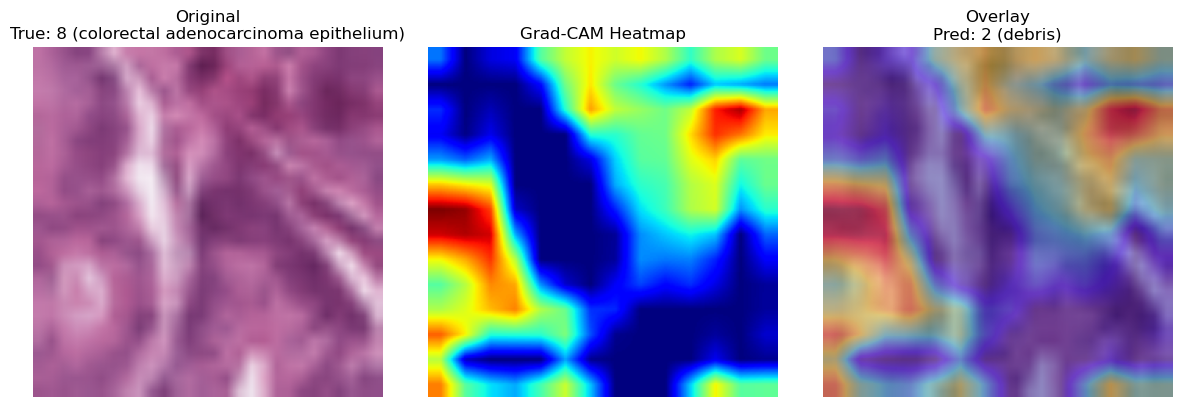

In [19]:
sample_img, sample_label = test_dataset[0]
input_tensor = sample_img.unsqueeze(0).to(device)
input_tensor.requires_grad_(True)

mask, logit = gradcam(input_tensor)

pred_class = logit.argmax(dim=1).item()
true_label = sample_label.item() if hasattr(sample_label, "item") else int(sample_label)

show_gradcam_result(
    input_tensor,
    mask,
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225],
    label_map=label_map,
    true_label=true_label,
    pred_label=pred_class,
)

## Multi-sample Grad-CAM

Three blocks: **(1) one image per class**, **(2) correct vs incorrect predictions**, **(3) several images of one class (mucus)**.  
Run in the same kernel after `gradcam`, `model`, `device`, `label_map`, and `pretrainVGG_transform` are defined.

In [20]:
# --- Multi-sample Grad-CAM: shared setup (224 + ImageNet norm, same as training) ---
from gradcam_utils import show_gradcam_grid

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

gcam_test_ds = PathMNIST(split="test", transform=pretrainVGG_transform, download=True)


def _y_int(y):
    y = torch.as_tensor(y).squeeze()
    return int(y.item())


def _label_name(idx):
    return label_map.get(str(idx), label_map.get(idx, str(idx)))


def gradcam_batch_one(img_chw, class_idx=None):
    """class_idx=None: CAM for predicted class; int: CAM for that class logit."""
    x = img_chw.unsqueeze(0).to(device).float().clone()
    x.requires_grad_(True)
    mask, logits = gradcam(x, class_idx=class_idx)
    return x.detach(), mask, logits


model.eval()

Using downloaded and verified file: /Users/zhangzimo/.medmnist/pathmnist.npz


pretrainVGG16_PathMNIST(
  (vgg16): VGG(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU()
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU()
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU()
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU()
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU()
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU()
      (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=

Picked 5 of 6 correctly predicted mucus, indices: [910, 925, 2348, 5472, 6389]


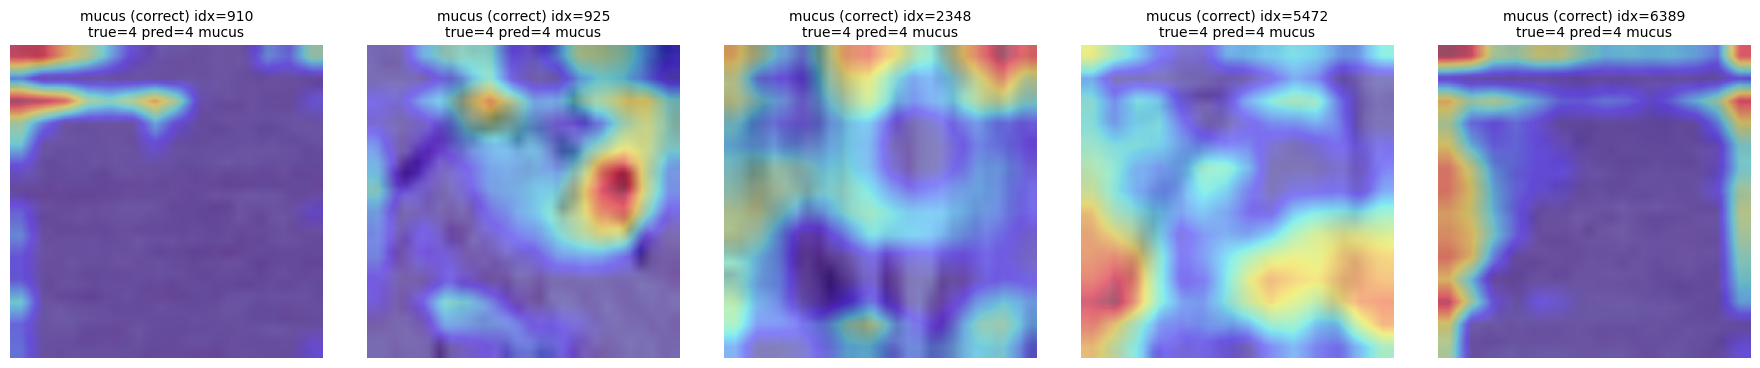

In [ ]:
# (1) Same class, several images: true mucus (label 4) AND predicted mucus — stability for correct same-class predictions.
MUCUS_CLASS = 4
N_SAMPLES = 5

mucus_correct_indices = []
with torch.no_grad():
    for idx in range(len(gcam_test_ds)):
        img, y = gcam_test_ds[idx]
        ty = _y_int(y)
        if ty != MUCUS_CLASS:
            continue
        logits = model(img.unsqueeze(0).to(device).float())
        pred = logits.argmax(dim=1).item()
        if pred == MUCUS_CLASS:
            mucus_correct_indices.append(idx)

total_mucus_correct = len(mucus_correct_indices)
mucus_correct_indices = mucus_correct_indices[:N_SAMPLES]

if total_mucus_correct < N_SAMPLES:
    print(
        f"Warning: only {total_mucus_correct} test images are true mucus AND predicted mucus "
        f"(wanted {N_SAMPLES}). Train a stronger model or lower N_SAMPLES."
    )
else:
    print(
        f"Picked {len(mucus_correct_indices)} of {total_mucus_correct} correctly predicted mucus, indices: {mucus_correct_indices}"
    )

imgs, masks, titles = [], [], []
for idx in mucus_correct_indices:
    img, y = gcam_test_ds[idx]
    inp, mask, logits = gradcam_batch_one(img, class_idx=MUCUS_CLASS)
    pred = logits.argmax(dim=1).item()
    imgs.append(inp)
    masks.append(mask)
    titles.append(
        f"mucus (correct) idx={idx}\ntrue={MUCUS_CLASS} pred={pred} {_label_name(pred)[:16]}"
    )

if imgs:
    show_gradcam_grid(imgs, masks, titles, IMAGENET_MEAN, IMAGENET_STD, ncols=min(len(imgs), N_SAMPLES))


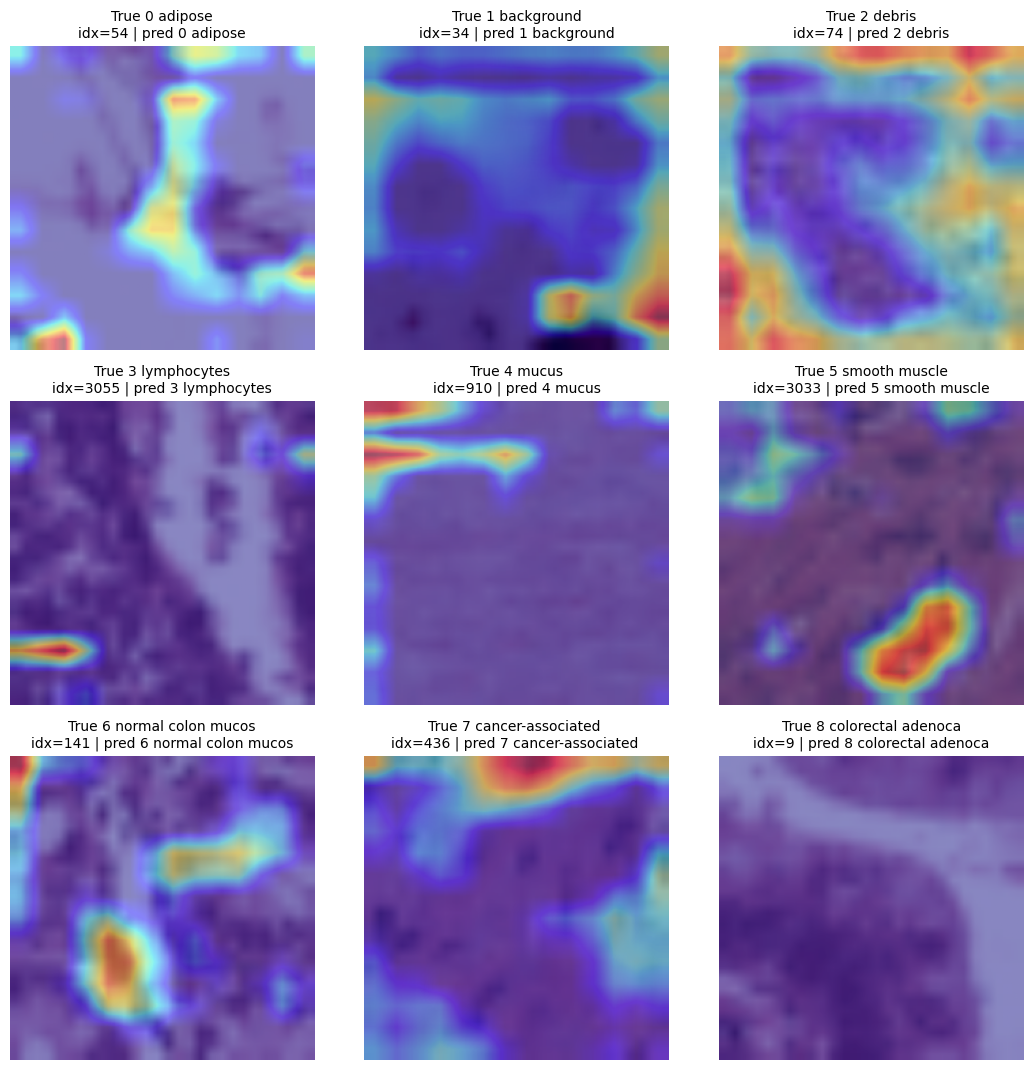

In [ ]:
# (2) One image per true class. Grad-CAM uses the true-class logit for cross-class comparison of attended regions.
num_classes = len(label_map)
per_class_correct = {}

for idx in range(len(gcam_test_ds)):
    img, y = gcam_test_ds[idx]
    c = _y_int(y)

    inp, _, logits = gradcam_batch_one(img, class_idx=c)
    pred = logits.argmax(dim=1).item()

    if pred == c and c not in per_class_correct:
        per_class_correct[c] = idx

    if len(per_class_correct) >= num_classes:
        break

if len(per_class_correct) < num_classes:
    print(f"Warning: only found {len(per_class_correct)} classes with correct predictions.")

imgs, masks, titles = [], [], []

for c in sorted(per_class_correct.keys()):
    idx = per_class_correct[c]
    img, y = gcam_test_ds[idx]

    inp, mask, logits = gradcam_batch_one(img, class_idx=c)
    pred = logits.argmax(dim=1).item()

    imgs.append(inp)
    masks.append(mask)

    titles.append(
        f"True {c} {_label_name(c)[:18]}\n"
        f"idx={idx} | pred {pred} {_label_name(pred)[:18]}"
    )

show_gradcam_grid(
    imgs,
    masks,
    titles,
    IMAGENET_MEAN,
    IMAGENET_STD,
    ncols=3
)

Correct: 3 images, incorrect: 3 (target 3 each)


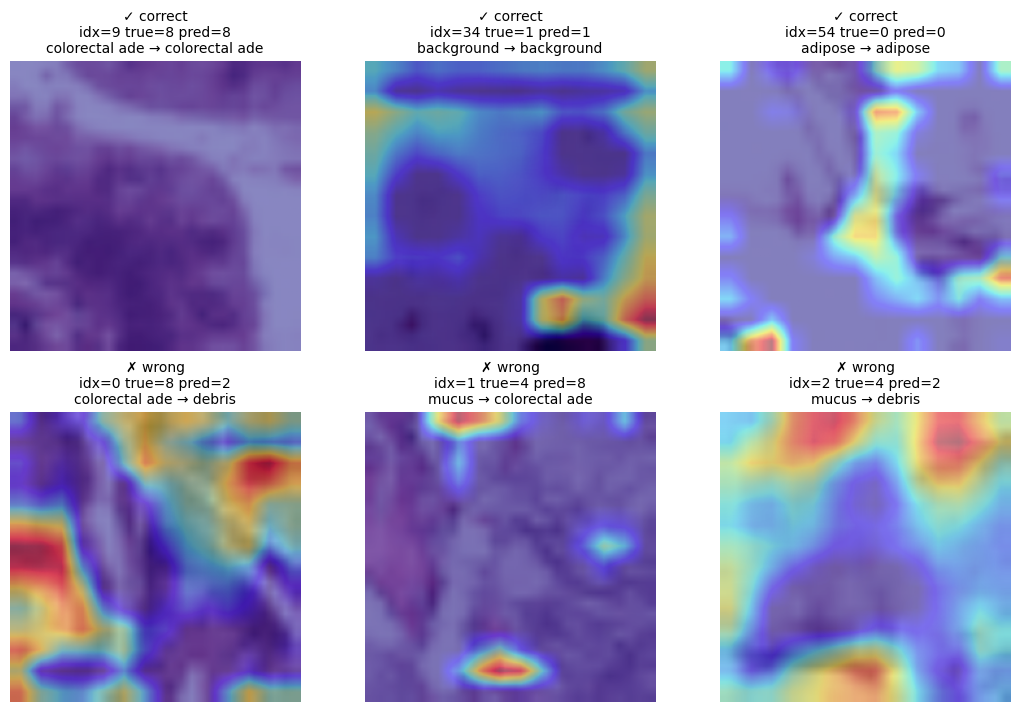

In [ ]:
# (3) Correct vs incorrect: pick several each. CAM uses the predicted class (see if wrong samples look chaotic or off-target).
target_class = 4   # 例如 mucus
N_EACH = 3

correct_meta, wrong_meta = [], []

with torch.no_grad():
    for idx in range(len(gcam_test_ds)):
        if len(correct_meta) >= N_EACH and len(wrong_meta) >= N_EACH:
            break

        img, y = gcam_test_ds[idx]
        ty = _y_int(y)

        # 只看同一 true class
        if ty != target_class:
            continue

        logits = model(img.unsqueeze(0).to(device).float())
        pred = logits.argmax(dim=1).item()

        if pred == ty and len(correct_meta) < N_EACH:
            correct_meta.append((idx, img, ty, pred))
        elif pred != ty and len(wrong_meta) < N_EACH:
            wrong_meta.append((idx, img, ty, pred))

print(
    f"Class {target_class} ({_label_name(target_class)}): "
    f"correct={len(correct_meta)}, wrong={len(wrong_meta)}"
)

imgs, masks, titles = [], [], []

for tag, meta_list in [("✓ correct", correct_meta), ("✗ wrong", wrong_meta)]:
    for idx, img, ty, pred in meta_list:
        # 这里建议还是用 predicted class 做 Grad-CAM
        inp, mask, logits = gradcam_batch_one(img, class_idx=None)

        imgs.append(inp)
        masks.append(mask)
        titles.append(
            f"{tag}\nidx={idx} true={ty} pred={pred}\n"
            f"{_label_name(ty)[:14]} → {_label_name(pred)[:14]}"
        )

show_gradcam_grid(imgs, masks, titles, IMAGENET_MEAN, IMAGENET_STD, ncols=3)